In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df=pd.read_csv('/content/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [72]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [74]:
df=df.drop(columns=['CustomerID'])
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [75]:
col_to_fix=[
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies'
]


for col in col_to_fix:
  df[col]=df[col].replace({'No internet service':'No'})


In [76]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


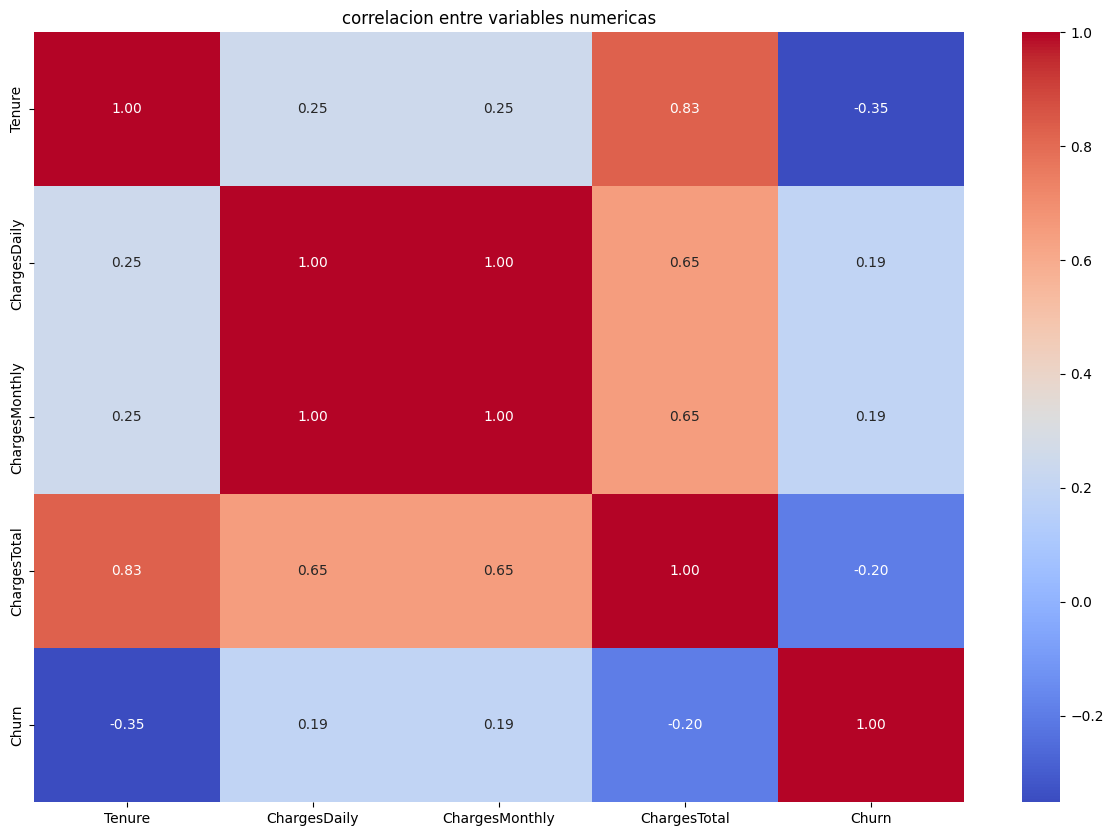

In [77]:
numerica=df.select_dtypes(include=['float64','int64'])
numerica['Churn']=df['Churn'].map({'Yes':1,'No':0})

correlacion=numerica.corr()

plt.figure(figsize=(15,10))
sns.heatmap(correlacion,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlacion entre variables numericas')
plt.show()

In [78]:
df=df.drop(columns=['ChargesTotal','ChargesDaily'])

In [79]:
categoricas=df.select_dtypes(include=['object']).columns
categoricas=categoricas.drop('Churn')

In [80]:
for col in categoricas:
  print(f'\n Analisis de variable: {col}')
  display(pd.crosstab(df[col],df['Churn'],normalize='index')*100)



 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [81]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [82]:
ranking=df.copy()
ranking['Churn']=ranking['Churn'].map({'Yes':1,'No':0})
categoricas=ranking.select_dtypes(include=['object']).columns

le=LabelEncoder()
for col in categoricas:
  ranking[col]=le.fit_transform(ranking[col])

x_categoricas=ranking[categoricas]
y=ranking['Churn']

chi_scores,p_values=chi2(x_categoricas,y)

chi_df=pd.DataFrame({
    'variable':categoricas,
    'chi2 score':chi_scores,
    'p-value':p_values

})

chi_df=chi_df.sort_values(by='chi2 score',ascending=False)
chi_df


,variable,chi2 score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [83]:
significativas=chi_df[chi_df['p-value']<0.05]

print('Ranking')
display(chi_df)

print('variables significativas (P<0.05)')
display(significativas)

selected_features=significativas['variable'].tolist()

print('variables seleccionadas')
display(selected_features)



Ranking


,variable,chi2 score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


variables significativas (P<0.05)


,variable,chi2 score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


variables seleccionadas


['Contract',
 'OnlineSecurity',
 'TechSupport',
 'SeniorCitizen',
 'Dependents',
 'PaperlessBilling',
 'Partner',
 'PaymentMethod',
 'OnlineBackup',
 'DeviceProtection',
 'StreamingTV',
 'StreamingMovies',
 'InternetService',
 'MultipleLines']

In [84]:
df=df.drop(columns=['Gender','PhoneService'])
df

,Churn,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Yes,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Yes,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [85]:
X=df.drop(columns=['Churn'],axis=1)
y=df['Churn']


In [86]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)



In [87]:
X_train=pd.get_dummies(X_train,drop_first=True)

X_test=pd.get_dummies(X_test,drop_first=True)

X_train,X_test=X_train.align(X_test,join='left',axis=1,fill_value=0)


In [88]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

In [96]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1409 entries, 455 to 5658
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 1409 non-null   int64  
 1   ChargesMonthly                         1409 non-null   float64
 2   SeniorCitizen_Yes                      1409 non-null   bool   
 3   Partner_Yes                            1409 non-null   bool   
 4   Dependents_Yes                         1409 non-null   bool   
 5   MultipleLines_Yes                      1409 non-null   bool   
 6   InternetService_Fiber optic            1409 non-null   bool   
 7   InternetService_No                     1409 non-null   bool   
 8   OnlineSecurity_Yes                     1409 non-null   bool   
 9   OnlineBackup_Yes                       1409 non-null   bool   
 10  DeviceProtection_Yes                   1409 non-null   bool   
 11  TechSup

In [97]:
X_test

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
455,21,28.50,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
2301,11,111.40,True,False,False,True,True,False,False,True,True,True,True,True,False,False,True,False,True,False
2255,4,69.35,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
4527,5,19.95,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
3812,72,65.65,False,True,True,False,False,False,True,True,True,True,True,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,1,19.15,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True
4510,3,80.50,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False
3910,1,55.25,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False
4820,24,74.80,False,True,True,True,False,False,True,False,False,False,True,True,True,False,False,False,False,True


In [90]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


In [91]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model=LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)

y_pred_normal=log_model.predict(X_test)

print('regresion logistica')
print(classification_report(y_test,y_pred_normal))

regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [92]:
from sklearn.ensemble import RandomForestClassifier
treemodel= RandomForestClassifier(random_state=42)
treemodel.fit(X_train,y_train)

y_pred=treemodel.predict(X_test)

print('arbol de decision')
print(classification_report(y_test,y_pred))

arbol de decision
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [93]:
from sklearn.linear_model import LogisticRegression

log_model=LogisticRegression(max_iter=1000,class_weight='balanced')
log_model.fit(X_train,y_train)

y_pred=log_model.predict(X_test)

print('regresion logistica')
print(classification_report(y_test,y_pred))

regresion logistica
              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



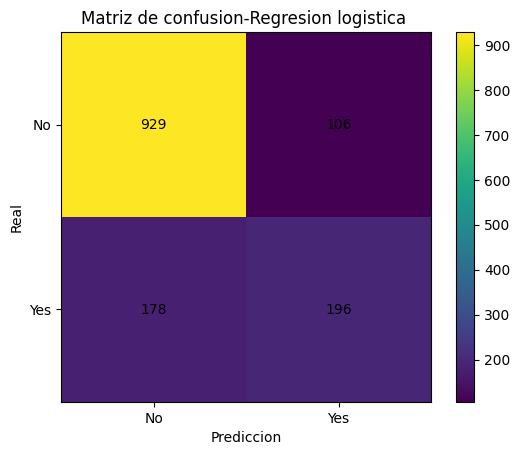

In [94]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cn=confusion_matrix(y_test,y_pred_normal)

plt.figure()
plt.imshow(cn)
plt.title('Matriz de confusion-Regresion logistica ')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.colorbar()

for i in range(cn.shape[0]):
  for j in range(cn.shape[1]):
    plt.text(j,i,cn[i,j],ha='center',va='center')
plt.xticks([0,1],['No','Yes'])
plt.yticks([0,1],['No','Yes'])
plt.show()

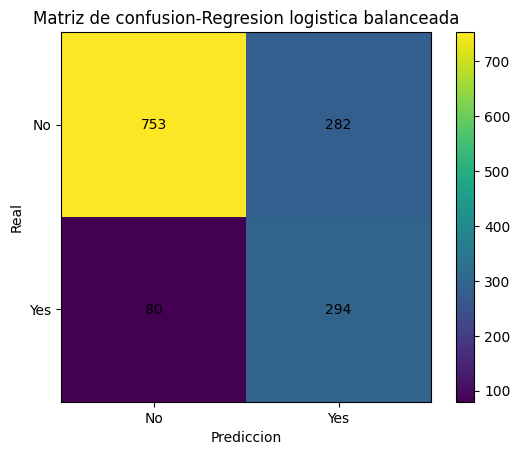

In [95]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cn=confusion_matrix(y_test,y_pred)

plt.figure()
plt.imshow(cn)
plt.title('Matriz de confusion-Regresion logistica balanceada')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.colorbar()

for i in range(cn.shape[0]):
  for j in range(cn.shape[1]):
    plt.text(j,i,cn[i,j],ha='center',va='center')
plt.xticks([0,1],['No','Yes'])
plt.yticks([0,1],['No','Yes'])
plt.show()

# Conclusiones del Análisis de Churn — TelecomX (Parte 2)

## 1. Panorama General del Dataset

- **7,043 clientes** analizados con **21 variables** (tras eliminar `CustomerID`).
- La variable objetivo (`Churn`) está **desbalanceada**: ~73.5% No vs ~26.5% Sí.
- No se encontraron valores nulos después de la limpieza.

---

## 2. Variables Eliminadas por Baja Relevancia

| Variable eliminada | Razón |
|---|---|
| `ChargesTotal` y `ChargesDaily` | Alta correlación con `ChargesMonthly` (redundancia) |
| `Gender` | Chi² = 0.26, p = 0.61 → **sin relación con el churn** |
| `PhoneService` | Chi² = 0.10, p = 0.76 → **sin relación con el churn** |

---

## 3. Factores Clave del Churn (Chi-Cuadrado)

| # | Variable | Chi² Score | Interpretación |
|---|---|---|---|
| 1 | **Contract** | 1,115.78 | Factor **dominante**. Mes a mes → 42.7% churn vs Dos años → 2.8% |
| 2 | **OnlineSecurity** | 147.30 | Sin seguridad online → 31.3% churn vs Con ella → 14.6% |
| 3 | **TechSupport** | 135.56 | Sin soporte técnico → 31.2% churn vs Con él → 15.2% |
| 4 | **SeniorCitizen** | 134.35 | Adultos mayores → 41.7% churn vs No senior → 23.6% |
| 5 | **Dependents** | 133.04 | Sin dependientes → 31.3% churn vs Con ellos → 15.5% |
| 6 | **PaperlessBilling** | 105.68 | Facturación digital → 33.6% churn vs Papel → 16.3% |
| 7 | **PaymentMethod** | 58.49 | Cheque electrónico → **45.3%** churn (el más alto de todos) |

---

## 4. Perfiles de Alto Riesgo

Los clientes con **mayor probabilidad de cancelación** combinan:

- 📅 Contrato **mes a mes**
- 💳 Pago por **cheque electrónico**
- 🔓 **Sin** seguridad online ni soporte técnico
- 👤 **Adulto mayor**, sin pareja y sin dependientes
- 📧 Facturación **sin papel** (digital)
- 🔗 Internet por **fibra óptica** (41.9% churn vs DSL 19%)

---

## 5. Rendimiento de los Modelos

| Modelo | Accuracy | Precision (Sí) | Recall (Sí) | F1 (Sí) |
|---|---|---|---|---|
| Regresión Logística | **80%** | 0.65 | 0.52 | 0.58 |
| Random Forest | 78% | 0.62 | 0.48 | 0.54 |
| Reg. Logística **Balanceada** | 74% | 0.51 | **0.79** | **0.62** |

### Análisis:

- **Regresión Logística estándar** tiene la mejor accuracy (80%), pero solo detecta el **52%** de los clientes que realmente cancelan.
- **Random Forest** tuvo el peor desempeño general en esta configuración.
- **Regresión Logística Balanceada** es el **modelo más útil para el negocio** porque:
  - Detecta el **79%** de los clientes que van a cancelar (recall = 0.79)
  - Aunque genera más falsos positivos (precision baja a 0.51), es preferible intervenir de más que perder clientes

> [!IMPORTANT]
> **Mejor modelo para retención:** Regresión Logística Balanceada. El costo de no detectar un cliente que cancela (falso negativo) es mucho mayor que el costo de ofrecer retención a uno que no iba a cancelar (falso positivo).

---

## 6. Recomendaciones Estratégicas

1. **Migrar contratos mensuales a anuales**: Ofrecer descuentos o beneficios por compromisos de 1–2 años.
2. **Redesign del cobro electrónico**: Investigar por qué cheque electrónico tiene el churn más alto (45.3%) — posible fricción en el proceso.
3. **Bundling de servicios de seguridad**: Ofrecer paquetes con seguridad online + soporte técnico, especialmente a clientes sin estos servicios.
4. **Programa especial para adultos mayores**: Atención personalizada y planes simplificados.
5. **Alertas tempranas**: Implementar el modelo balanceado para identificar clientes en riesgo y activar campañas de retención proactivas.
6. **Revisar servicio de fibra óptica**: El churn de fibra (41.9%) es más del doble que DSL (19%). Posibles problemas de calidad de servicio o expectativas de precio.